# Numerical Columns

## Setting a Ground Truth

In order to determine which imputation method performs best, we apply a Missing Completely At Random (MCAR) mechanism to the cleaned DataFrame and compare the imputed values with the original observed values using evaluation metrics.

In [18]:
import pandas as pd
from taxipred.utils.constants import TAXI_CSV_PATH

df = pd.read_csv(TAXI_CSV_PATH)
df.info()

# the original DF where we have 5% null values per column,

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       950 non-null    float64
 1   Time_of_Day            950 non-null    object 
 2   Day_of_Week            950 non-null    object 
 3   Passenger_Count        950 non-null    float64
 4   Traffic_Conditions     950 non-null    object 
 5   Weather                950 non-null    object 
 6   Base_Fare              950 non-null    float64
 7   Per_Km_Rate            950 non-null    float64
 8   Per_Minute_Rate        950 non-null    float64
 9   Trip_Duration_Minutes  950 non-null    float64
 10  Trip_Price             951 non-null    float64
dtypes: float64(7), object(4)
memory usage: 86.1+ KB


In [19]:
df_clean = df.dropna().copy()
df_clean.info()

# this will be our ground truth and we will applying 5% MCAR for each column just like we have observed in our original DF.

<class 'pandas.core.frame.DataFrame'>
Index: 562 entries, 0 to 998
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       562 non-null    float64
 1   Time_of_Day            562 non-null    object 
 2   Day_of_Week            562 non-null    object 
 3   Passenger_Count        562 non-null    float64
 4   Traffic_Conditions     562 non-null    object 
 5   Weather                562 non-null    object 
 6   Base_Fare              562 non-null    float64
 7   Per_Km_Rate            562 non-null    float64
 8   Per_Minute_Rate        562 non-null    float64
 9   Trip_Duration_Minutes  562 non-null    float64
 10  Trip_Price             562 non-null    float64
dtypes: float64(7), object(4)
memory usage: 52.7+ KB


In [20]:
import numpy as np

# getting rid of the non-numeric columns

numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
df_clean_num = df_clean[numeric_cols].copy()
df_clean_num.info()

<class 'pandas.core.frame.DataFrame'>
Index: 562 entries, 0 to 998
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       562 non-null    float64
 1   Passenger_Count        562 non-null    float64
 2   Base_Fare              562 non-null    float64
 3   Per_Km_Rate            562 non-null    float64
 4   Per_Minute_Rate        562 non-null    float64
 5   Trip_Duration_Minutes  562 non-null    float64
 6   Trip_Price             562 non-null    float64
dtypes: float64(7)
memory usage: 35.1 KB


In [21]:
# applying MCAR mechanism at 5% 

mask_matrix = pd.DataFrame(
    np.random.rand(*df_clean_num.shape) < 0.05,
    index=df_clean_num.index,
    columns=df_clean_num.columns
)

df_masked_num = df_clean_num.mask(mask_matrix)

df_masked_num.info()

<class 'pandas.core.frame.DataFrame'>
Index: 562 entries, 0 to 998
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       533 non-null    float64
 1   Passenger_Count        531 non-null    float64
 2   Base_Fare              531 non-null    float64
 3   Per_Km_Rate            537 non-null    float64
 4   Per_Minute_Rate        534 non-null    float64
 5   Trip_Duration_Minutes  537 non-null    float64
 6   Trip_Price             537 non-null    float64
dtypes: float64(7)
memory usage: 35.1 KB


## Imputation

I will be applying different imputation methods on the "Ground Truth" dataset and compare evaluation performances to decide which one fits better to fill the null values on the original data.

### Mean Imputation
- This method involves replacing missing values with the mean of the relevant variable. It's a simple approach but it doesn't account for the relationships between variables.

In [22]:
from sklearn.impute import SimpleImputer

mean_imputer = SimpleImputer(strategy="mean")
df_mean = pd.DataFrame(
    mean_imputer.fit_transform(df_masked_num),
    columns=df_masked_num.columns,
    index=df_masked_num.index
)

df_mean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 562 entries, 0 to 998
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       562 non-null    float64
 1   Passenger_Count        562 non-null    float64
 2   Base_Fare              562 non-null    float64
 3   Per_Km_Rate            562 non-null    float64
 4   Per_Minute_Rate        562 non-null    float64
 5   Trip_Duration_Minutes  562 non-null    float64
 6   Trip_Price             562 non-null    float64
dtypes: float64(7)
memory usage: 35.1 KB


### Linear Imputation

- Pros: captures trends, preserves relationships
- Cons: assumes a pattern (linear) may be complex

In [23]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import LinearRegression

linear_imputer = IterativeImputer(
    estimator=LinearRegression(),
    max_iter=1,               # key: one pass (linear regression baseline)
    random_state=42,
    sample_posterior=False
)

df_linear = pd.DataFrame(
    linear_imputer.fit_transform(df_masked_num),
    columns=df_masked_num.columns,
    index=df_masked_num.index
)

df_linear.info()


<class 'pandas.core.frame.DataFrame'>
Index: 562 entries, 0 to 998
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       562 non-null    float64
 1   Passenger_Count        562 non-null    float64
 2   Base_Fare              562 non-null    float64
 3   Per_Km_Rate            562 non-null    float64
 4   Per_Minute_Rate        562 non-null    float64
 5   Trip_Duration_Minutes  562 non-null    float64
 6   Trip_Price             562 non-null    float64
dtypes: float64(7)
memory usage: 35.1 KB


/home/apollonspc/taxi-prediction-fullstack-omer-aytug/.venv/lib/python3.14/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


### MICE Imputation
- MICE (Multiple Imputation by Chained Equations) style chained equations (iterative regression imputation) to preserve relationships between variables.

In [24]:
mice_imputer = IterativeImputer(
    estimator=LinearRegression(),
    random_state=42,
    max_iter=20,
    sample_posterior=False
)

df_mice = pd.DataFrame(
    mice_imputer.fit_transform(df_masked_num),
    columns=df_masked_num.columns,
    index=df_masked_num.index
)


df_mice.info()

<class 'pandas.core.frame.DataFrame'>
Index: 562 entries, 0 to 998
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       562 non-null    float64
 1   Passenger_Count        562 non-null    float64
 2   Base_Fare              562 non-null    float64
 3   Per_Km_Rate            562 non-null    float64
 4   Per_Minute_Rate        562 non-null    float64
 5   Trip_Duration_Minutes  562 non-null    float64
 6   Trip_Price             562 non-null    float64
dtypes: float64(7)
memory usage: 35.1 KB


## Evaluation
- RMSE/MAE only on masked cells

In [25]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Only evaluate at positions we intentionally masked
y_true   = df_clean_num.values[mask_matrix.values]
y_mean   = df_mean.values[mask_matrix.values]
y_linear = df_linear.values[mask_matrix.values]
y_mice   = df_mice.values[mask_matrix.values]

def rmse(y_t, y_p):
    return np.sqrt(mean_squared_error(y_t, y_p))

def mae(y_t, y_p):
    return mean_absolute_error(y_t, y_p)

results = pd.DataFrame({
    "RMSE": [rmse(y_true, y_mean), rmse(y_true, y_linear), rmse(y_true, y_mice)],
    "MAE":  [mae(y_true, y_mean),  mae(y_true, y_linear),  mae(y_true, y_mice)]
}, index=["Mean", "LinearRegression", "MICE"])

display(results.sort_values("RMSE"))



,RMSE,MAE
MICE,11.943886,6.024595
LinearRegression,12.638852,6.298375
Mean,19.924898,9.877180


- Structure check (varience comparison)

In [26]:
var_compare = pd.DataFrame({
    "True (df_clean_num)": df_clean_num.var(),
    "Mean Imputed": df_mean.var(),
    "Linear Imputed": df_linear.var(),
    "MICE": df_mice.var()
})

display(var_compare)


,True (df_clean_num),Mean Imputed,Linear Imputed,MICE
Trip_Distance_km,447.456825,390.450032,450.002262,450.766671
Passenger_Count,1.229693,1.169871,1.171633,1.171870
Base_Fare,0.758784,0.709827,0.710213,0.710208
Per_Km_Rate,0.185202,0.176763,0.177679,0.179514
Per_Minute_Rate,0.013187,0.012476,0.012535,0.012687
Trip_Duration_Minutes,1032.236406,977.264902,980.528088,988.580713
Trip_Price,1932.370937,1907.380853,1939.306751,1940.774485


### Plot Evaluation

- Analyzing the performance of our imputation models by comparing imputed valued with the actual values for some of the columns

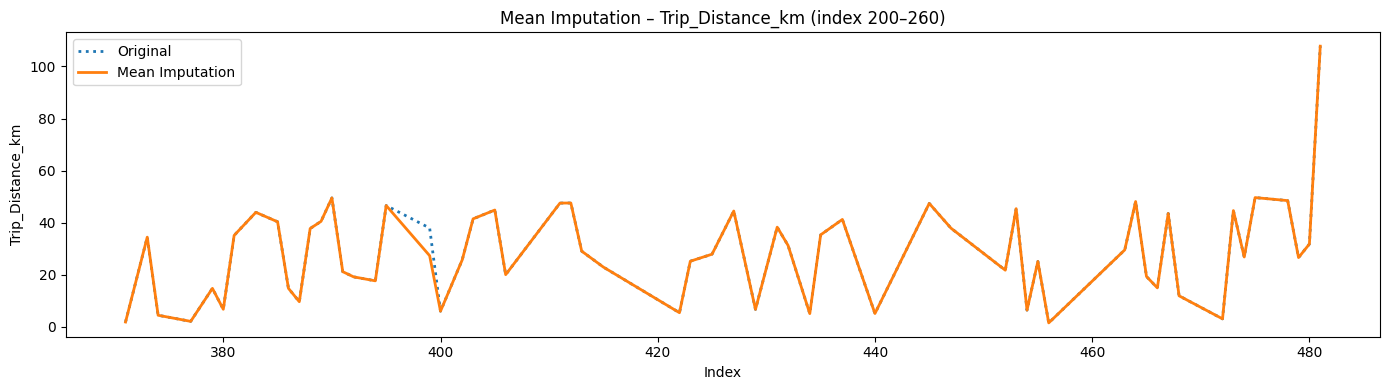

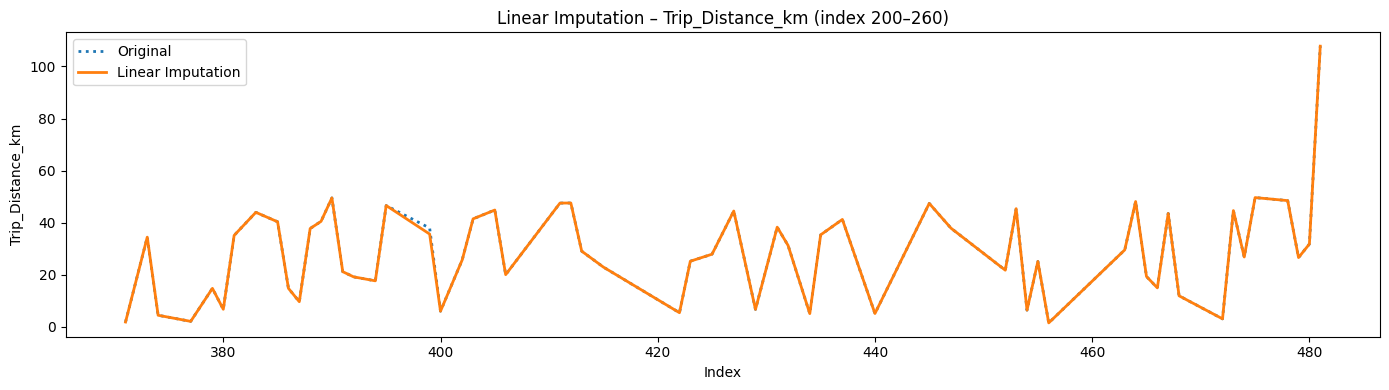

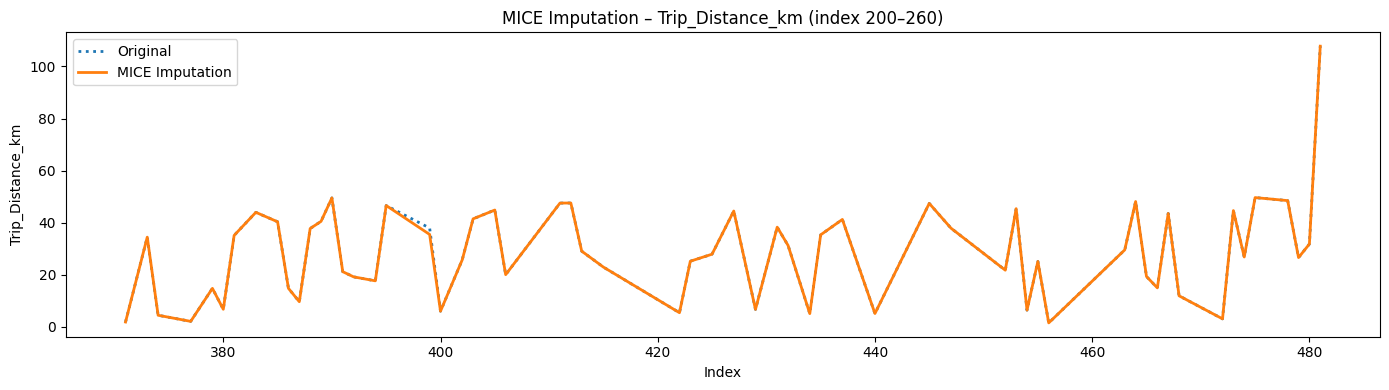

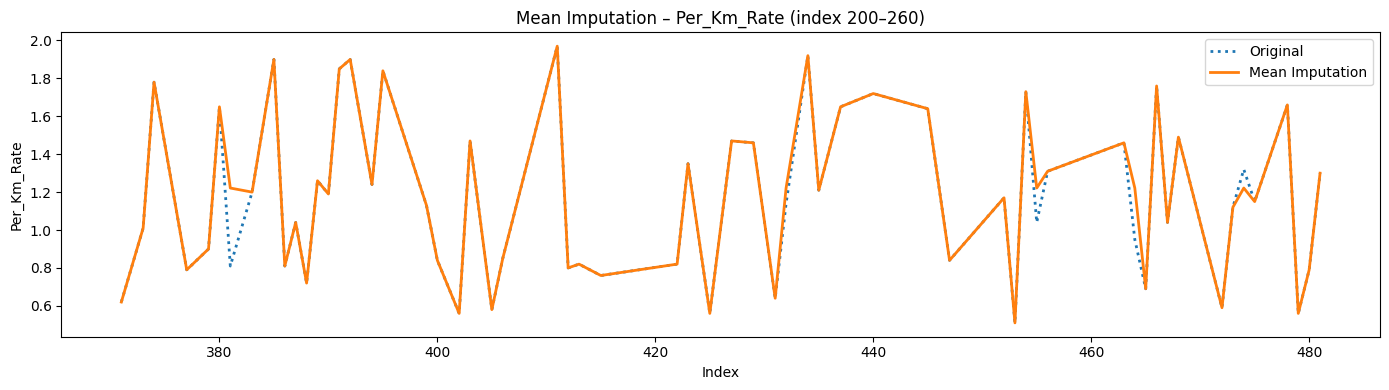

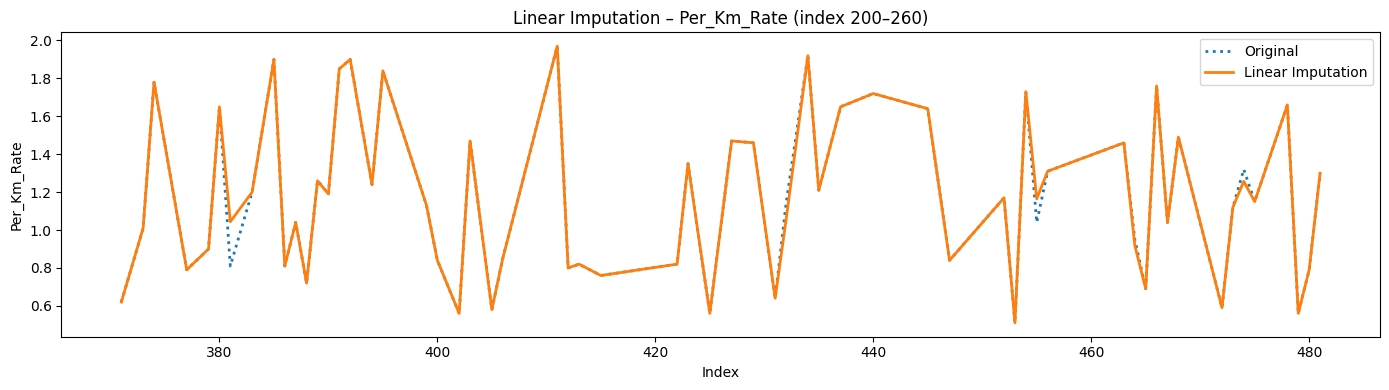

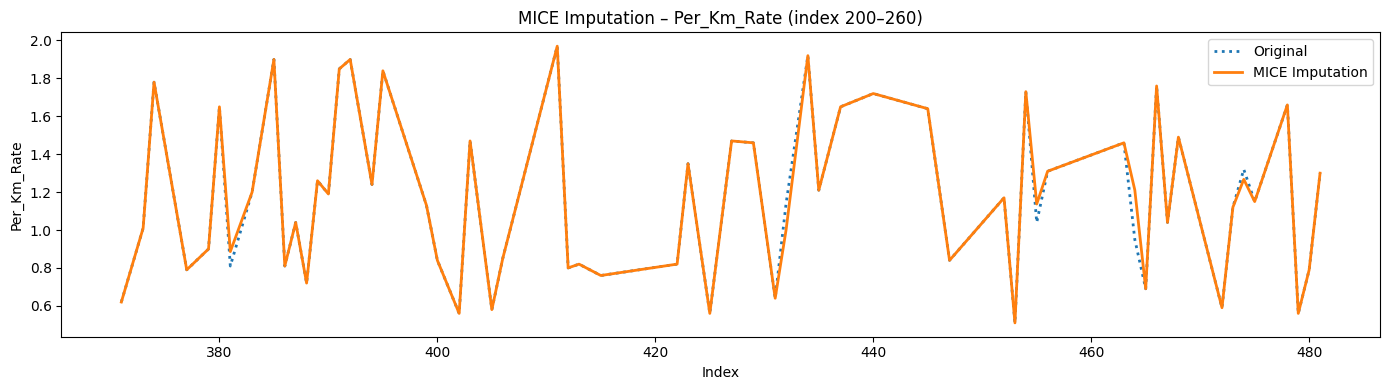

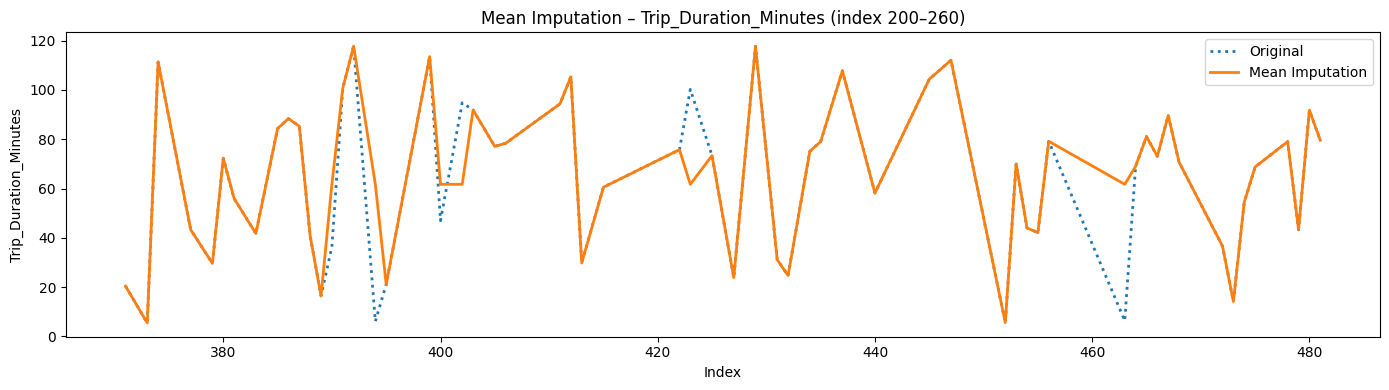

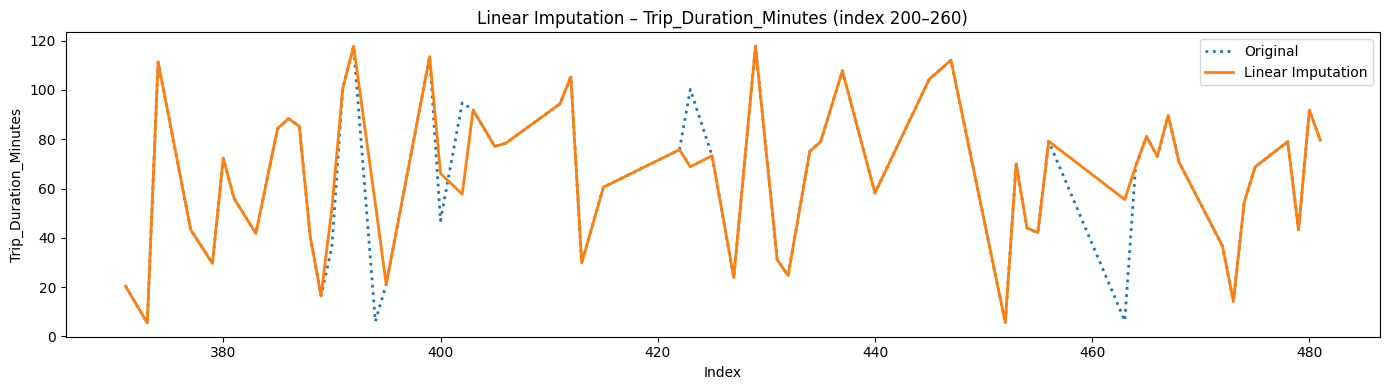

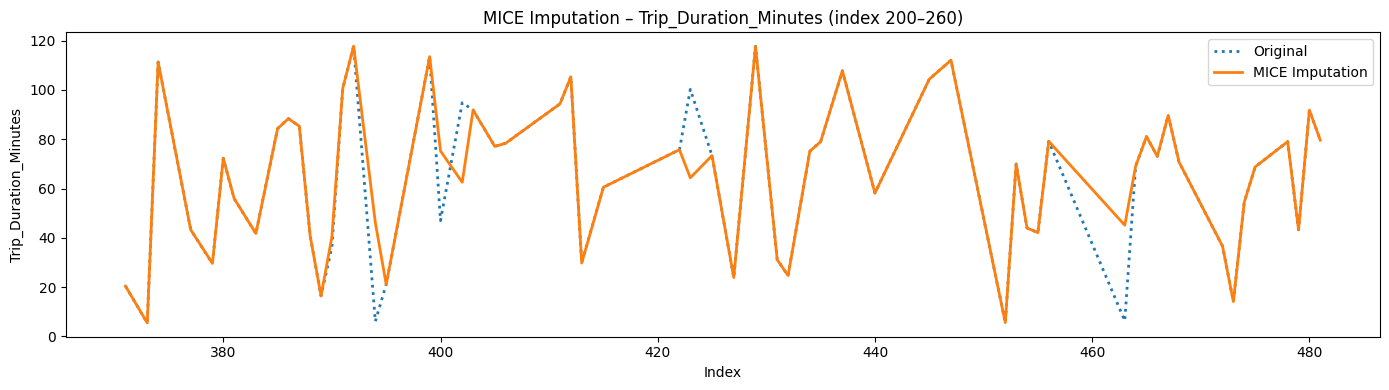

In [27]:
import matplotlib.pyplot as plt

cols_to_check = [
    "Trip_Distance_km",
    "Per_Km_Rate",
    "Trip_Duration_Minutes"
]

start, end = 200, 260   # zoom window

methods = {
    "Mean Imputation": df_mean,
    "Linear Imputation": df_linear,
    "MICE Imputation": df_mice
}

for col in cols_to_check:
    for method_name, df_imp in methods.items():
        plt.figure(figsize=(14, 4))

        # Original (ground truth)
        plt.plot(
            df_clean[col].iloc[start:end],
            label="Original",
            linestyle="dotted",
            linewidth=2
        )

        # Imputed version
        plt.plot(
            df_imp[col].iloc[start:end],
            label=method_name,
            linewidth=2
        )

        plt.title(f"{method_name} – {col} (index {start}–{end})")
        plt.xlabel("Index")
        plt.ylabel(col)
        plt.legend()
        plt.tight_layout()
        plt.show()


- Analyzing our imputation models based on their distributation performance

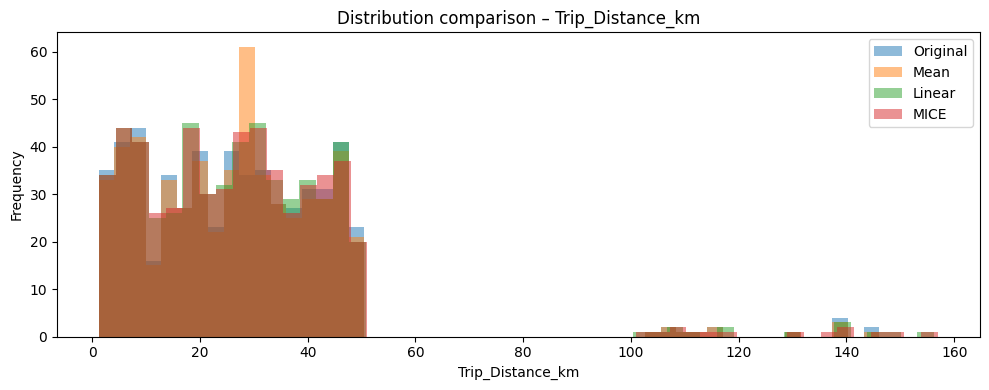

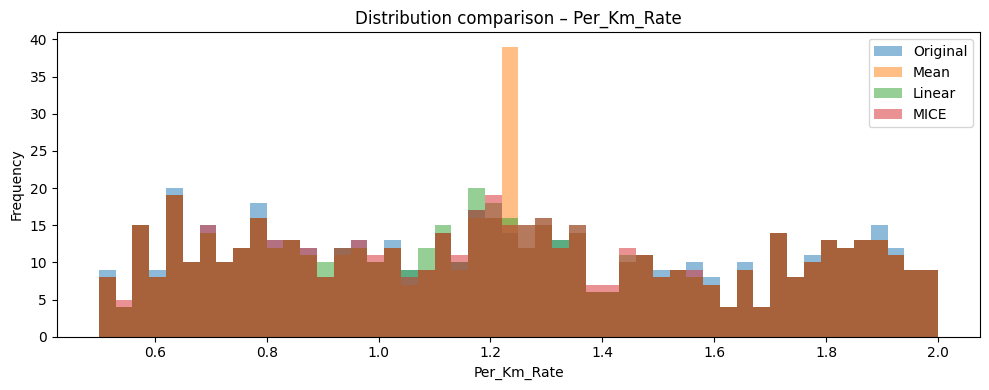

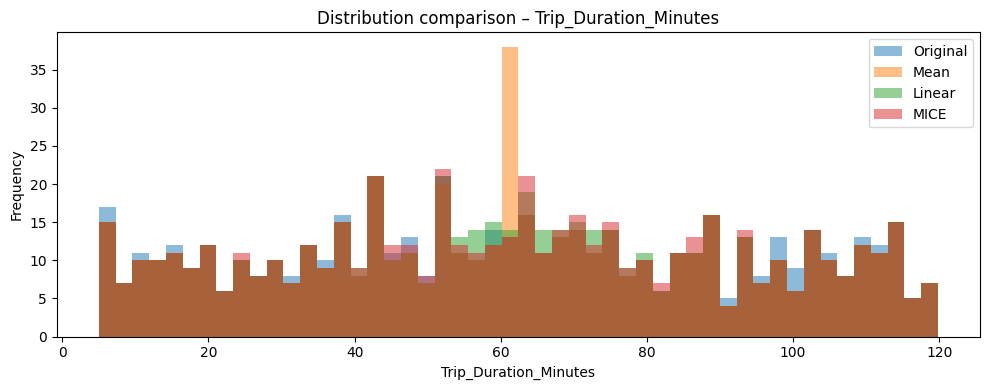

In [28]:
for col in cols_to_check:
    plt.figure(figsize=(10, 4))

    plt.hist(df_clean_num[col], bins=50, alpha=0.5, label="Original")
    plt.hist(df_mean[col], bins=50, alpha=0.5, label="Mean")
    plt.hist(df_linear[col], bins=50, alpha=0.5, label="Linear")
    plt.hist(df_mice[col], bins=50, alpha=0.5, label="MICE")

    plt.title(f"Distribution comparison – {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.legend()
    plt.tight_layout()
    plt.show()


# Categorical Columns
- Categorical variables contained missing values that could not be handled by row deletion without substantial data loss. Therefore, imputation methods will be applied to recover missing categories while preserving the underlying structure of the data.

## Setting a Ground Truth

- Just like we did for the numerical columns, we are going to get rid of our null values and apply a 5% MCAR for the clean data. 

In [29]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

In [30]:
def create_mcar_mask(df, col, frac=0.05, random_state=42):
    np.random.seed(random_state)
    idx = df[df[col].notna()].sample(frac=frac).index
    return idx

## Imputation

### Model Imputation
- Missing categories will be imputed using supervised classification models that predict values based on observed numerical and categorical features. This method will be used if it achieves higher macro-F1 scores.

In [31]:
def evaluate_model_imputation(df, cat_col, num_cols, cat_cols, mask_idx):

    df_eval = df.copy()

    true_values = df_eval.loc[mask_idx, cat_col]
    df_eval.loc[mask_idx, cat_col] = np.nan

    df_imputed = impute_categorical_column(
        df_eval,
        cat_col,
        num_cols,
        cat_cols
    )

    preds = df_imputed.loc[mask_idx, cat_col]

    return {
        "accuracy": accuracy_score(true_values, preds),
        "f1_macro": f1_score(true_values, preds, average="macro")
    }


### Mode Imputation (Most-Frequent)
- Missing categories are imputed using the most-frequent value for variables with high class imbalance or when model-based imputation does not improve performance.

In [32]:
def evaluate_most_frequent_imputation(df, cat_col, mask_idx):

    df_eval = df.copy()

    true_values = df_eval.loc[mask_idx, cat_col]
    df_eval.loc[mask_idx, cat_col] = np.nan

    imputer = SimpleImputer(strategy="most_frequent")
    df_eval[[cat_col]] = imputer.fit_transform(df_eval[[cat_col]])

    preds = df_eval.loc[mask_idx, cat_col]

    return {
        "accuracy": accuracy_score(true_values, preds),
        "f1_macro": f1_score(true_values, preds, average="macro")
    }


### Imputer

In [33]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

def impute_categorical_column(df, target_col, num_cols, cat_cols, random_state=42):
    """
    Model-based imputation for a single categorical column.
    """

    df = df.copy()

    # rows with / without missing target
    train_idx = df[target_col].notna()
    test_idx  = df[target_col].isna()

    # nothing to impute
    if test_idx.sum() == 0:
        return df

    X_train = df.loc[train_idx].drop(columns=[target_col])
    y_train = df.loc[train_idx, target_col]
    X_test  = df.loc[test_idx].drop(columns=[target_col])

    # predictors
    num_features = num_cols
    cat_features = [c for c in cat_cols if c != target_col]

    # preprocessing
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", "passthrough", num_features),
            ("cat", Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]), cat_features)
        ]
    )

    # classifier
    model = RandomForestClassifier(
        n_estimators=200,
        random_state=random_state,
        n_jobs=-1,
        class_weight="balanced"
    )

    pipe = Pipeline(steps=[
        ("prep", preprocessor),
        ("clf", model)
    ])

    # fit + predict
    pipe.fit(X_train, y_train)
    df.loc[test_idx, target_col] = pipe.predict(X_test)

    return df


## Evaluation

In [34]:
for col in cat_cols:
    mask_idx = create_mcar_mask(df, col)

    mode_scores  = evaluate_most_frequent_imputation(df, col, mask_idx)
    model_scores = evaluate_model_imputation(df, col, num_cols, cat_cols, mask_idx)

    print(col)
    print("  Mode :", mode_scores)
    print("  Model:", model_scores)


NameError: name 'accuracy_score' is not defined